In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

import xgboost as xgb
import lightgbm as lgb

In [3]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
print(train.shape)
print(test.shape)

train.head()

(198000, 15)
(102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
e

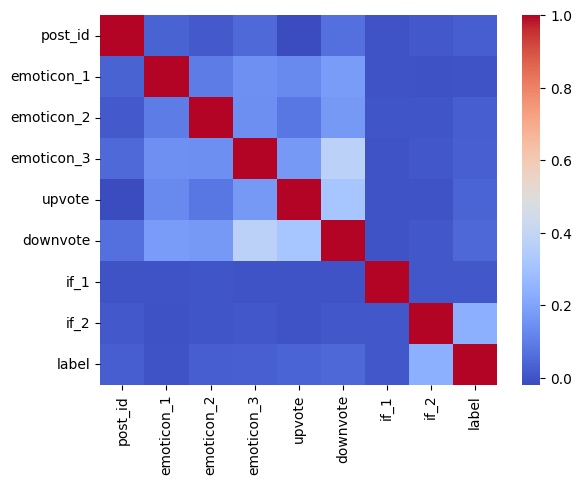

In [4]:
print(train.info())

print(train.isnull().sum())

num_data = train.select_dtypes(include=np.number)

sns.heatmap(num_data.corr(), cmap="coolwarm")
plt.show()

In [5]:
X = train.drop("label", axis=1)
y = train["label"]

In [6]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [7]:
preprocess = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)



In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


1st Model : Logistic Regression

In [9]:
pipe_lr = Pipeline(
    [
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=500))
    ]
)

pipe_lr.fit(X_train, y_train)

pred_lr = pipe_lr.predict(X_val)

print("Logistic:", accuracy_score(y_val, pred_lr))

Logistic: 0.8731060606060606


2nd Model : RandomForest

In [10]:
pipe_rf = Pipeline(
    [
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=10,
            n_jobs=-1,
            random_state=42
        ))
    ]
)

pipe_rf.fit(X_train,y_train)

pred_rf = pipe_rf.predict(X_val)
print("RandomForest:", accuracy_score(y_val,pred_rf))

RandomForest: 0.569040404040404


Model3 : KNN

In [11]:
pipe_knn = Pipeline(
    [
        ("prep", preprocess),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]
)

pipe_knn.fit(X_train, y_train)

pred_knn = pipe_knn.predict(X_val)

print("KNN:", accuracy_score(y_val, pred_knn))

KNN: 0.8342676767676768


Model 4: XGBoost

In [12]:
pipe_xgb = Pipeline(
    [
        ("prep", preprocess),
        ("model", xgb.XGBClassifier(
            n_estimators=300,
            max_depth=7,
            learning_rate=0.04,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
        ))
    ]
)

pipe_xgb.fit(X_train, y_train)

pred_xgb = pipe_xgb.predict(X_val)

print("XGB:", accuracy_score(y_val, pred_xgb))

XGB: 0.8762878787878788


Model 5: LightBGM

In [13]:
pipe_lgb = Pipeline(
    [
        ("prep", preprocess),
        ("model", lgb.LGBMClassifier(
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=31
        ))
    ]
)

pipe_lgb.fit(X_train, y_train)

pred_lgb = pipe_lgb.predict(X_val)

print("LGB:", accuracy_score(y_val, pred_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 373
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 30
[LightGBM] [Info] Start training from score -0.547267
[LightGBM] [Info] Start training from score -2.523600
[LightGBM] [Info] Start training from score -1.159078
[LightGBM] [Info] Start training from score -3.592651


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGB: 0.8758080808080808


In [14]:
scores = {}

scores["Logistic"] = accuracy_score(y_val, pred_lr)
scores["RF"] = accuracy_score(y_val, pred_rf)
scores["KNN"] = accuracy_score(y_val, pred_knn)
scores["XGB"] = accuracy_score(y_val, pred_xgb)
scores["LGB"] = accuracy_score(y_val, pred_lgb)

print(scores)

{'Logistic': 0.8731060606060606, 'RF': 0.569040404040404, 'KNN': 0.8342676767676768, 'XGB': 0.8762878787878788, 'LGB': 0.8758080808080808}


In [15]:
best_name = max(scores, key=scores.get)

print("Best model:", best_name)

Best model: XGB


In [16]:
models = {
    "Logistic": pipe_lr,
    "RF": pipe_rf,
    "KNN": pipe_knn,
    "XGB": pipe_xgb,
    "LGB": pipe_lgb
}

best_model = models[best_name]


In [17]:
best_model.fit(X, y)

test_pred = best_model.predict(test)


In [18]:
submission = pd.DataFrame({
    "label": test_pred
})

submission.to_csv("submission.csv", index=False)

submission.head()

,label
0,2
1,2
2,0
3,0
4,2


X = train_df["comment"]
y = train_df["label"]

# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train.values.reshape(-1, 1), y_train)

# Validation accuracy
y_val_pred = dummy.predict(X_val.values.reshape(-1, 1))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

# Test predictions
test_preds = dummy.predict(test_df["comment"].values.reshape(-1, 1))

submission = pd.DataFrame({
    "ID": sample_df["ID"],
    "label": test_preds
})

submission.to_csv("submission.csv", index=False)

train_df.shape

test_df.shape[1]

train_df.select_dtypes(include = ['object']).shape

train_df.select_dtypes(include = [np.number]).shape

train_df.select_dtypes(include = ['bool'])

train_df.columns[train_df.isnull().any()]

train_df['upvote'].median()

train_df.select_dtypes(include = [np.number]).max()

train_df['if_2'].min()

train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

print("Shape:", train.shape)
print("\nColumns:", train.columns.tolist())
print("\nData Types:\n", train.dtypes)
print("\nFirst 3 rows:\n", train.head(3))
print("\nMissing Values:\n", train.isnull().sum())
print("\nLabel distribution:\n", train['label'].value_counts().sort_index())
print("\nSample 'comment' values:\n", train['comment'].dropna().head(3).tolist())
print("\nNumerical columns stats:\n", train[["post_id", "emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2"]].describe())
print("\nCategorical unique values:")
for col in ["race", "religion", "gender", "disability"]:
    print(f"  {col}: {train[col].nunique()} unique →", train[col].unique()[:5])

train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
train['comment'] = train['comment'].fillna('')

X = train.drop(columns=['label'])
y = train['label']

# Part A: Stratified
X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
    X, y, test_size=0.4, random_state=2306, stratify=y
)
train_counts_A = np.array(y_train_A.value_counts().sort_index())
val_counts_A   = np.array(y_val_A.value_counts().sort_index())
print("Q1A - Train counts (stratified):", train_counts_A)
print("Q1A - Val counts   (stratified):", val_counts_A)

# Part B: Non-Stratified
X_train_B, X_val_B, y_train_B, y_val_B = train_test_split(
    X, y, test_size=0.4, random_state=2306, stratify=None
)
train_counts_B = np.array(y_train_B.value_counts().sort_index())
val_counts_B   = np.array(y_val_B.value_counts().sort_index())
print("Q1B - Train counts (non-stratified):", train_counts_B)
print("Q1B - Val counts   (non-stratified):", val_counts_B)

# Part C: Max absolute difference in proportions
prop_A = val_counts_A / val_counts_A.sum()
prop_B = val_counts_B / val_counts_B.sum()
max_diff = np.max(np.abs(prop_A - prop_B))
print(f"\nQ1C - Max absolute difference: {max_diff:.4f}")

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import re 

train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
train['comment'] = train['comment'].fillna('')
X = train.drop(columns=['label'])
y = train['label']

# Stratified split
X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
    X, y, test_size=0.4, random_state=2306, stratify=y
)

# Step 1: Drop created_date
x_train = X_train_A.copy().drop(columns=['created_date'])
x_test  = X_val_A.copy().drop(columns=['created_date'])
y_train = y_train_A.copy()
y_test  = y_val_A.copy()

# Step 2: Extract text
text_x_train = x_train['comment']
text_x_test  = x_test['comment']
x_train = x_train.drop(columns=['comment'])
x_test  = x_test.drop(columns=['comment'])

# Step 3: ColumnTransformer
cat_cols = ["race", "religion", "gender", "disability"]
num_cols = ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
            "upvote", "downvote", "if_1", "if_2"]

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ],
    remainder='passthrough'
)

x_train_tabular = preprocessor.fit_transform(x_train)
x_test_tabular  = preprocessor.transform(x_test)

# Step 4: Text Cleaning — NOTE: double space as per question
def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', '  ', text).strip()
    return text

text_x_train_norm = text_x_train.apply(normalize_text)
text_x_test_norm  = text_x_test.apply(normalize_text)

# Step 5: TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tf_idf_train = tfidf.fit_transform(text_x_train_norm)
tf_idf_test  = tfidf.transform(text_x_test_norm)

# Step 6: Combine
X_train_final = hstack([x_train_tabular, tf_idf_train])
X_test_final  = hstack([x_test_tabular, tf_idf_test])

print(f"X_train_final shape: {X_train_final.shape}")
print(f"Q2 - Sum of all values in X_train_final: {X_train_final.sum():.3f}")

from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# SVD — fit only on X_train_final
svd = TruncatedSVD(n_components=300, random_state=2306)
X_train_reduced = svd.fit_transform(X_train_final)
X_test_reduced  = svd.transform(X_test_final)

print(f"X_train_reduced shape: {X_train_reduced.shape}")
print(f"X_test_reduced shape:  {X_test_reduced.shape}")

# Q3 — RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 10, 15]
}

rf = RandomForestClassifier(random_state=2306)

randomized_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    random_state=2306,
    n_jobs=-1
)

randomized_search.fit(X_train_reduced, y_train)

print(f"\nQ3 - Best params: {randomized_search.best_params_}")
print(f"Q3 - Best n_estimators: {randomized_search.best_params_['n_estimators']}")